# Gibbs Sampler with Metropolis Transition-Rate Function

Interactive runner for `gibbs_sampler_core.py`. Each section below is a
notebook cell you can run independently and re-run with different
parameters, instead of a single top-to-bottom script that used to stop
partway through (there was a hard `raise ValueError` in the original
script used purely as a manual "stop here" marker during interactive
development).

**Requirements:** `numpy`, `scipy`, `matplotlib`, `qutip`. Put
`gibbs_sampler_core.py` in the same folder as this notebook (or on your
`PYTHONPATH`).

## 1. Setup & parameters

In [3]:
import numpy as np
import matplotlib.pyplot as plt

import gibbs_sampler_BA as core

# ---- Model parameters ----
n_ = 3       # number of spins
J = 1        # coupling strength
h = 0.8      # transverse field strength
beta_ = 0.5  # inverse temperature

# ---- Transition rate ----
transition_rate_ = "metropolis"   # or "gaussian" (see core.TRANSITION_RATE_FUNCTIONS)

model = core.build_model(n_, J, h)
print("Hilbert space dimension:", model.H.shape[0])
print("Eigenvalues of H:", model.evals)

Hilbert space dimension: 8
Eigenvalues of H: [-3.63303028 -3.32409987  0.03303028  0.2         0.2         1.8
  1.8         2.92409987]


## 2. Discretize the energy/time domain

In [4]:
w_d, t_d, w_0, r_bound, N_disc = core.default_discretization(model, beta_)
print(f"N_disc = {N_disc}, r_bound = {r_bound:.3f}, w_0 = {w_0:.5f}")

N_disc = 3309, r_bound = 25.114, w_0 = 0.03036


## 4. Spectral gap vs. sigma, for several betas

This is the main (and most expensive) computation: for each beta, sweep
sigma_E and build/diagonalize the Lindbladian at each point.

In [ ]:
fig, ax = core.plot_spectral_gap_vs_sigma_all_betas(
    model,
    sigma_E_start=0.1, sigma_E_end=2.0, how_many=10,
    betas= np.linspace(0.1, 1, 5),
    w_d=w_d, t_d=t_d,
    transition_rate=transition_rate_,
)
plt.show()

## 5. Davies-generator upper bound (sigma -> 0 limit)

Two equivalent constructions of the exact (sigma = 0) Davies jump
operators, used as a reference/upper bound for the gap.

In [ ]:
jumps_v1 = core.create_jumps_for_sigma_0_version_1(model, w_d, beta_, transition_rate=transition_rate_)
jumps_v2 = core.create_jumps_for_sigma_0_version_2(model, w_d, beta_, transition_rate=transition_rate_)

print("Version 1:")
gap1 = core.give_Davies_gap(model, jumps_v1, beta_)
print("\nVersion 2:")
gap2 = core.give_Davies_gap(model, jumps_v2, beta_)

Version 1:
The Liouvillian satisfies detailed balance. Dist 1.497670626749532e-17
Davies gap: 0.019188602982779652

Version 2:
The Liouvillian satisfies detailed balance. Dist 1.62352455356514e-17
Davies gap: 0.019188602982779693


## 7. f(sigma) = 1 / (gap * sigma): a proxy for total mixing runtime

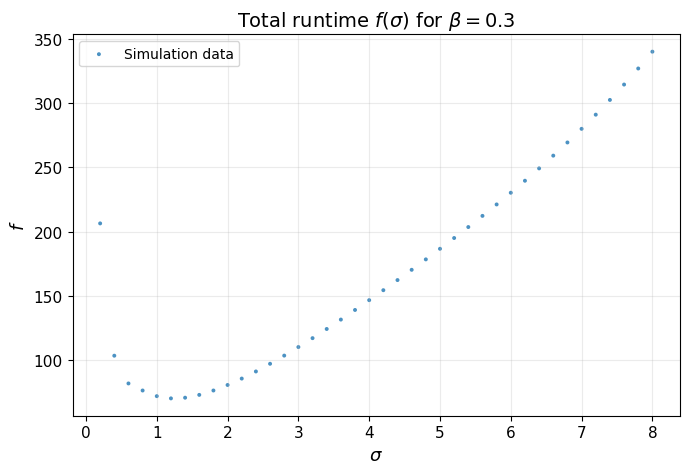

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/lorisweber/anaconda3/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 3460, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/90/shl_3hvn5nj3scpmvx8sr1480000gp/T/ipykernel_34732/1387980651.py", line 2, in <module>
    sigma_E_05, gaps_05, f_05 = core.u_form(model, 0.2, 8, 40, 0.5, w_d, t_d)
  File "/Users/lorisweber/Downloads/files-2/gibbs_sampler_core.py", line 644, in u_form
    import matplotlib.pyplot as plt
  File "/Users/lorisweber/Downloads/files-2/gibbs_sampler_core.py", line 427, in simulate_for_list_of_sigmas
  File "/Users/lorisweber/anaconda3/lib/python3.10/site-packages/qutip/core/superoperator.py", line 132, in liouvillian
    data = _data.add(data, _data.kron(spI, cdc), -0.5)
  File "qutip/core/data/dispatch.pyx", line 523, in qutip.core.data.dispatch.Dispatcher.__call__
  File "qutip/core/data/kron.pyx", line 29, in qutip.core.data.kron.kron_dense
  File "qutip/cor

In [ ]:
sigma_E_03, gaps_03, f_03 = core.u_form(model, 0.2, 8, 40, 0.3, w_d, t_d, transition_rate=transition_rate_)
sigma_E_05, gaps_05, f_05 = core.u_form(model, 0.2, 8, 40, 0.5, w_d, t_d, transition_rate=transition_rate_)

## 8. Find the optimal sigma for a range of betas

For each beta: locate the local minimum of f(sigma) via a
derivative sign-change scan, then refine it with golden-section search.

**Note:** this is the most expensive cell in the notebook (it runs a full
gap simulation many times per beta). Reduce the `bb` list or the
resolution (`anzahl`) below for a quick test run.

In [ ]:
bb = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6,
      0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 2, 2.5, 3]

list_with_gaps_for_different_betas = []
list_with_all_fs = []
list_with_all_derivatives = []
list_with_indices = []
lowers, highers = [], []
my_sigma_welle = []

for bbb in bb:
    sigma_E, gaps, f, derivative, list_indices = core.get_index_where_derivative_0(
        model, bbb, w_d, t_d, start=0.02, stop=3.0, anzahl=150, make_plot=True,
        transition_rate=transition_rate_,
    )
    list_with_gaps_for_different_betas.append(gaps)
    list_with_all_fs.append(f)
    list_with_all_derivatives.append(derivative)
    list_with_indices.append(list_indices)

    if len(list_indices) == 2:
        i1, i2 = list_indices
        if f[i1] < f[i2]:
            lower_sigma_E, higher_sigma_E = sigma_E[i1], sigma_E[i1 + 1]
        else:
            lower_sigma_E, higher_sigma_E = sigma_E[i2], sigma_E[i2 + 1]
    else:
        lower_sigma_E, higher_sigma_E = sigma_E[list_indices[0]], sigma_E[list_indices[0] + 1]

    lowers.append(lower_sigma_E)
    highers.append(higher_sigma_E)

    _, _, best_sigma = core.my_golden_section_search(
        model, lower_sigma_E, higher_sigma_E, bbb, w_d, t_d,
        transition_rate=transition_rate_,
    )
    my_sigma_welle.append(best_sigma)

print("Optimal sigma per beta:", my_sigma_welle)

## 9. Specific heat vs. optimal sigma

In [ ]:
betas_arr, C_values, C_normalized, sigma_normalized = core.compute_specific_heat_and_optimal_sigma(
    model, bb, my_sigma_welle,
)

fig, ax = plt.subplots()
ax.scatter(betas_arr, C_normalized, s=1, label='Specific Heat')
ax.scatter(betas_arr, sigma_normalized, s=1, label='Optimal sigma_E')
ax.set_xlabel(r'$\beta$')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()